In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("../data/telco_customer_churn.csv")

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits = 1, test_size = 0.2, random_state = 42)
for train_index, test_index in split.split(data, data["Churn"]):
    train_set = data.loc[train_index]
    test_set = data.loc[test_index]

In [5]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   str    
 1   gender            5634 non-null   str    
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   str    
 4   Dependents        5634 non-null   str    
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   str    
 7   MultipleLines     5634 non-null   str    
 8   InternetService   5634 non-null   str    
 9   OnlineSecurity    5634 non-null   str    
 10  OnlineBackup      5634 non-null   str    
 11  DeviceProtection  5634 non-null   str    
 12  TechSupport       5634 non-null   str    
 13  StreamingTV       5634 non-null   str    
 14  StreamingMovies   5634 non-null   str    
 15  Contract          5634 non-null   str    
 16  PaperlessBilling  5634 non-null   str    
 17  PaymentM

In [6]:
test_set.info()

<class 'pandas.DataFrame'>
Index: 1409 entries, 437 to 5613
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   str    
 1   gender            1409 non-null   str    
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   str    
 4   Dependents        1409 non-null   str    
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   str    
 7   MultipleLines     1409 non-null   str    
 8   InternetService   1409 non-null   str    
 9   OnlineSecurity    1409 non-null   str    
 10  OnlineBackup      1409 non-null   str    
 11  DeviceProtection  1409 non-null   str    
 12  TechSupport       1409 non-null   str    
 13  StreamingTV       1409 non-null   str    
 14  StreamingMovies   1409 non-null   str    
 15  Contract          1409 non-null   str    
 16  PaperlessBilling  1409 non-null   str    
 17  PaymentMe

In [7]:
compare = pd.DataFrame({
    "FULL":data["Churn"].value_counts(normalize=True),
    "TRAIN":train_set["Churn"].value_counts(normalize=True),
    "TEST":test_set["Churn"].value_counts(normalize=True),
})
print(compare)

          FULL     TRAIN      TEST
Churn                             
No     0.73463  0.734647  0.734564
Yes    0.26537  0.265353  0.265436


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [9]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.base import BaseEstimator, TransformerMixin

In [10]:
class StrToNum(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    def fit(self, X, y = None):
        self.fitted_ = True
        return self
    def transform(self, X, y = None):
        Y = X.copy()
        Y["TotalCharges"] = pd.to_numeric(Y["TotalCharges"], errors="coerce")
        return Y

In [11]:
pipeline = Pipeline([
    ("to_num", StrToNum()),
])

In [12]:
train_copy = train_set.copy()

In [13]:
pipeline.fit(train_copy)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('to_num', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False


In [14]:
new_train = pipeline.transform(train_copy)

In [15]:
new_train.info()

<class 'pandas.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   str    
 1   gender            5634 non-null   str    
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   str    
 4   Dependents        5634 non-null   str    
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   str    
 7   MultipleLines     5634 non-null   str    
 8   InternetService   5634 non-null   str    
 9   OnlineSecurity    5634 non-null   str    
 10  OnlineBackup      5634 non-null   str    
 11  DeviceProtection  5634 non-null   str    
 12  TechSupport       5634 non-null   str    
 13  StreamingTV       5634 non-null   str    
 14  StreamingMovies   5634 non-null   str    
 15  Contract          5634 non-null   str    
 16  PaperlessBilling  5634 non-null   str    
 17  PaymentM

In [16]:
new_train.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3738,4950-BDEUX,Male,0,No,No,35,No,No phone service,DSL,No,...,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,No
3151,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,No
4860,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,...,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,No
3867,4922-CVPDX,Female,0,Yes,No,26,Yes,No,DSL,No,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70,No
3810,2903-YYTBW,Male,0,Yes,Yes,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,No
2666,8414-OOEEL,Male,0,No,Yes,66,Yes,No,DSL,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),79.50,5196.10,No
2645,8562-GHPPI,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card (automatic),19.80,19.80,No
189,8017-UVSZU,Female,0,Yes,No,40,Yes,Yes,DSL,No,...,No,No,No,No,Month-to-month,No,Credit card (automatic),56.60,2379.10,No
5767,1972-XMUWV,Female,0,Yes,No,65,Yes,No,DSL,No,...,No,Yes,Yes,No,Two year,Yes,Credit card (automatic),59.80,3808.20,No
2257,2054-PJOCK,Female,0,No,No,60,Yes,Yes,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Credit card (automatic),80.55,4847.05,No


In [17]:
new_train['SeniorCitizen'].value_counts()

SeniorCitizen
0    4714
1     920
Name: count, dtype: int64

In [18]:
pd.crosstab(new_train["InternetService"], new_train["Churn"])

Churn,No,Yes
InternetService,,
DSL,1575,362
Fiber optic,1438,1045
No,1126,88


In [19]:
new_train.shape

(5634, 21)

In [20]:
new_train.drop_duplicates(inplace=True)

In [21]:
new_train.shape

(5634, 21)

In [22]:
def showCategories(data):
    data = data.copy()
    table = {
        "Column":[],
        "Num Categories":[],
        "Categories":[],
    }
    cat_col = data.select_dtypes(include="str").columns
    for col in cat_col:
        if col == "customerID":
            continue
        values = data[col].dropna().unique()
        
        table["Column"].append(col)
        table["Num Categories"].append(len(values))
        table["Categories"].append(values)

    pd.set_option("display.max_colwidth", None)
    return pd.DataFrame(table)

showCategories(new_train)

,Column,Num Categories,Categories
0,gender,2,"[Male, Female]"
1,Partner,2,"[No, Yes]"
2,Dependents,2,"[No, Yes]"
3,PhoneService,2,"[No, Yes]"
4,MultipleLines,3,"[No phone service, No, Yes]"
5,InternetService,3,"[DSL, Fiber optic, No]"
6,OnlineSecurity,3,"[No, Yes, No internet service]"
7,OnlineBackup,3,"[No, Yes, No internet service]"
8,DeviceProtection,3,"[Yes, No, No internet service]"
9,TechSupport,3,"[No, Yes, No internet service]"


In [23]:
import math

def clusteredChart(y, data, grid_col=2, size=(12, 4)):
    cols = data.select_dtypes(include="str").columns

    n = len(cols)
    rows = math.ceil(n / grid_col)

    fig, axes = plt.subplots(rows, grid_col, figsize=(size[0], size[1] * rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        if col == "customerID":
            continue
        chart = (
            data.groupby([col, y])
            .size()
            .unstack(fill_value = 0).apply(lambda x: x/x.sum(), axis = 1)*100
        )

        chart.plot(kind="bar", ax=axes[i])
        axes[i].set_title(f"{col} vs {y}")
        axes[i].tick_params(axis="x", rotation=45)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [24]:
def combinedData(data, y):
    pd_result = {
        "Yes":[],
        "No":[],
    }
    cols = data.select_dtypes(include="str").columns
    for col in cols:
        if col == "customerID": continue
        count_table = data.groupby([col, y]).size().unstack()
        percentage_table = data.groupby([col, y]).size().unstack(fill_value=0).apply(lambda x: x / x.sum(), axis = 1)*100

        
        result = pd.concat(
            [count_table.add_prefix("count_"), 
             percentage_table.add_suffix("_%")],
            axis = 1)

        print(f"\n==={col}===")
        print(result)

combinedData(new_train, "Churn")


===gender===
Churn   count_No  count_Yes       No_%      Yes_%
gender                                           
Female      2055        746  73.366655  26.633345
Male        2084        749  73.561595  26.438405

===Partner===
Churn    count_No  count_Yes       No_%      Yes_%
Partner                                           
No           1953        952  67.228916  32.771084
Yes          2186        543  80.102602  19.897398

===Dependents===
Churn       count_No  count_Yes       No_%      Yes_%
Dependents                                           
No              2715       1240  68.647282  31.352718
Yes             1424        255  84.812388  15.187612

===PhoneService===
Churn         count_No  count_Yes       No_%      Yes_%
PhoneService                                           
No                 424        135  75.849732  24.150268
Yes               3715       1360  73.201970  26.798030

===MultipleLines===
Churn             count_No  count_Yes       No_%      Yes_%
Multiple

In [25]:
churn_vs_payment = new_train.groupby("PaymentMethod")["Churn"].value_counts(normalize = True).unstack() * 100
print(churn_vs_payment)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.842444  16.157556
Credit card (automatic)    85.078318  14.921682
Electronic check           54.257007  45.742993
Mailed check               80.715397  19.284603


<Axes: xlabel='PaymentMethod'>

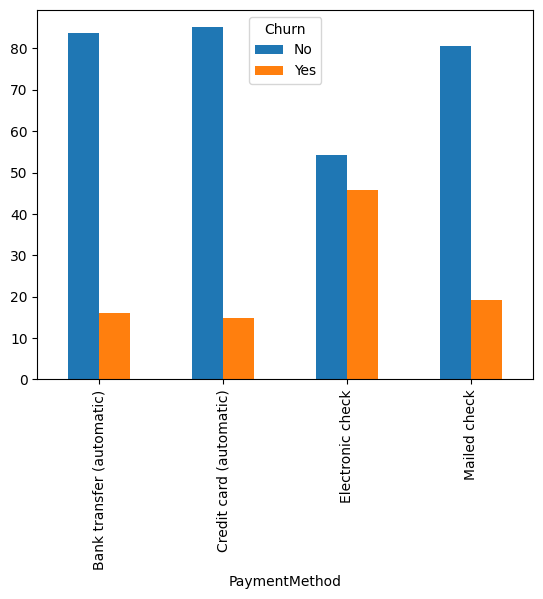

In [26]:
churn_vs_payment.plot(kind = "bar")

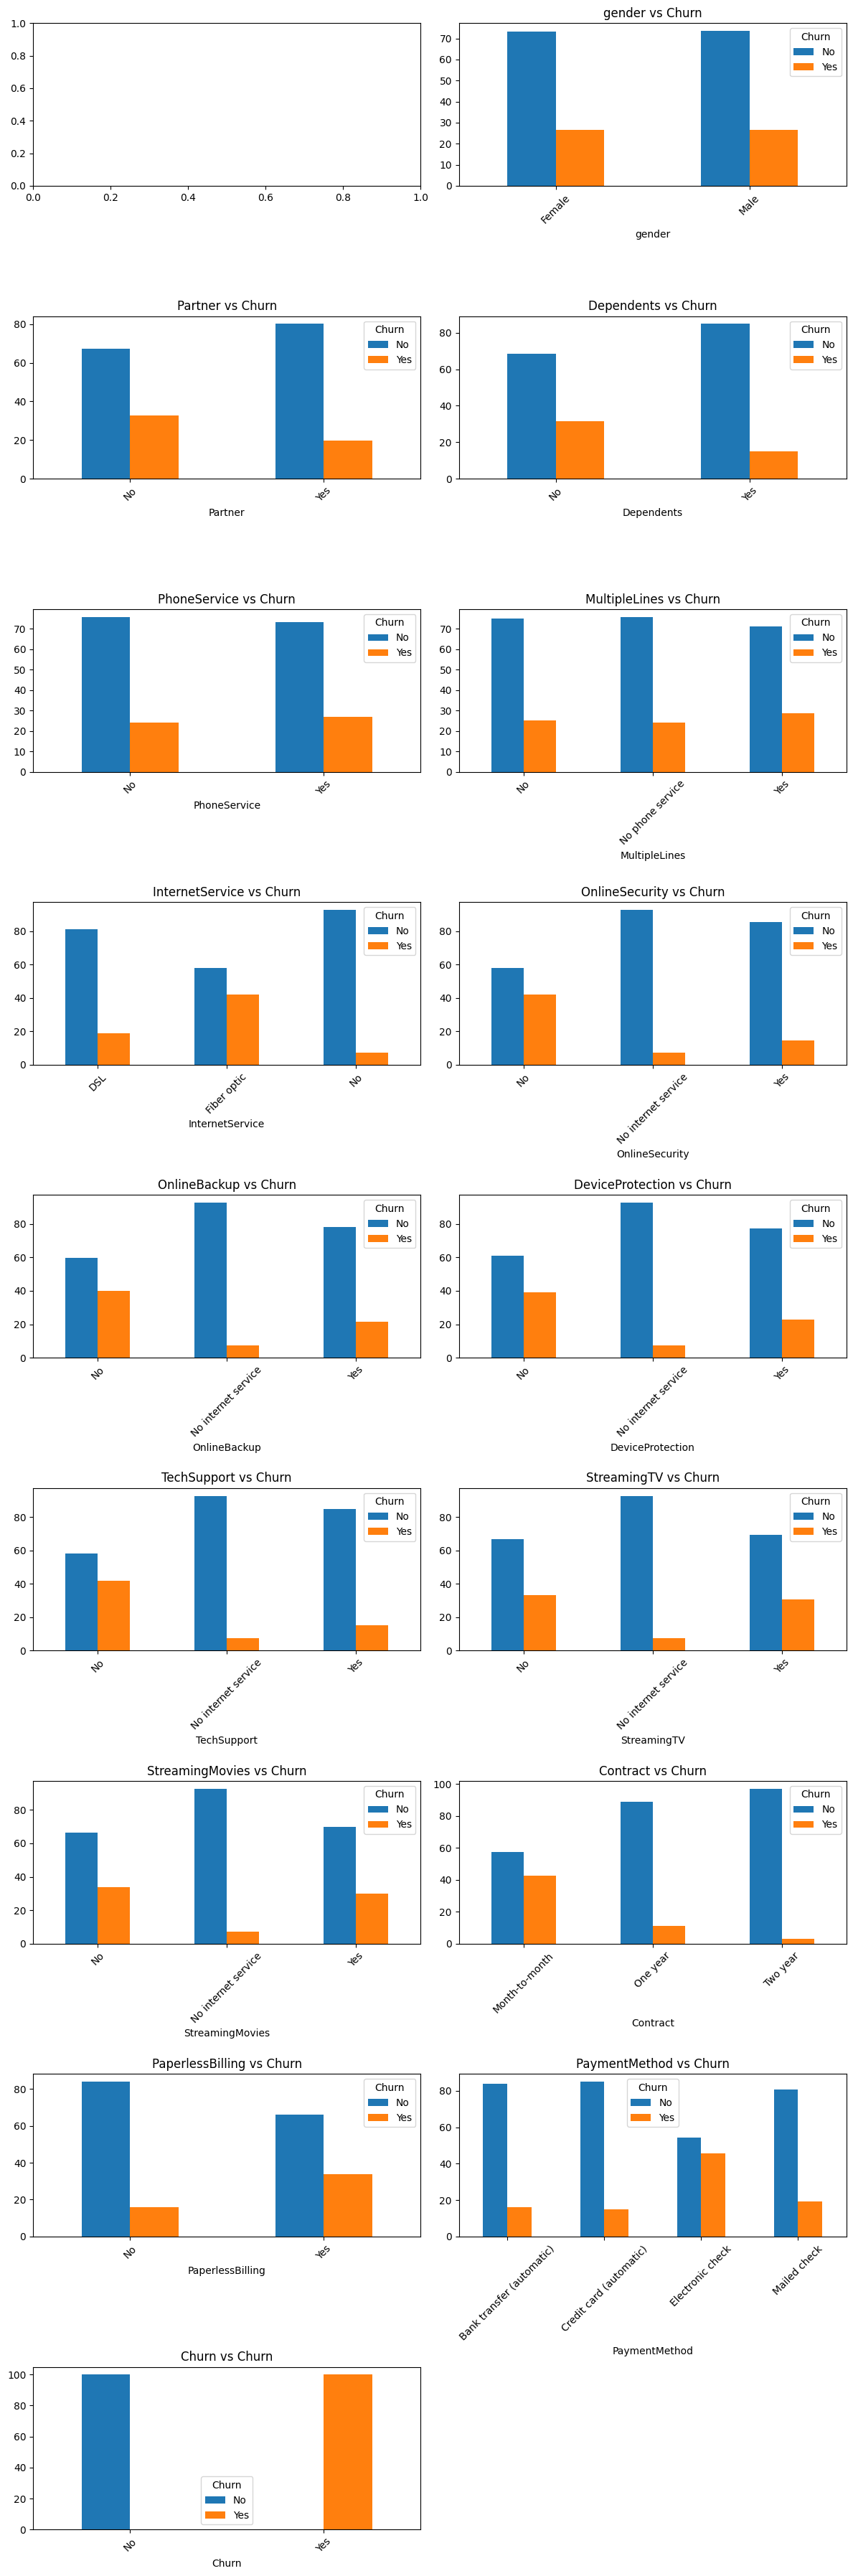

In [27]:
clusteredChart("Churn", new_train, 2, (12, 4))